# LGBM Full Analysis
### DATA3888 Group 8 — Stock volatility forecasting

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings("ignore")

INPUT_CSV  = r"d:\USYD\DATA3888\group_asm\optiver_aggregated.csv"
EVAL_CSV   = r"lgbm_outputs/lgbm_eval_results.csv"
PER_STOCK  = r"lgbm_outputs/lgbm_per_stock.csv"
FEAT_CSV   = r"lgbm_outputs/lgbm_feature_importance.csv"

N_CLUSTERS   = 4
N_TRAIN      = 16
RANDOM_STATE = 42

eval_df   = pd.read_csv(EVAL_CSV)
per_stock = pd.read_csv(PER_STOCK)
feat_imp  = pd.read_csv(FEAT_CSV)

agg       = pd.read_csv(INPUT_CSV)
train_raw = agg[agg["time_bucket"] <= N_TRAIN].copy()
val_raw   = agg[agg["time_bucket"] >  N_TRAIN].copy()

print(f"Eval sessions : {len(eval_df):,}")
print(f"Stocks        : {per_stock['stock_id'].nunique()}")

Eval sessions : 421,823
Stocks        : 112


## Old Analysis 1 — Stock Clustering

 cluster  n_stocks  mean_QLIKE     mean_MSE
       0        43  -14.125502 2.936143e-08
       1        36  -13.515130 7.141913e-08
       2        24  -13.005195 1.666531e-07
       3         9  -12.251874 3.383223e-07


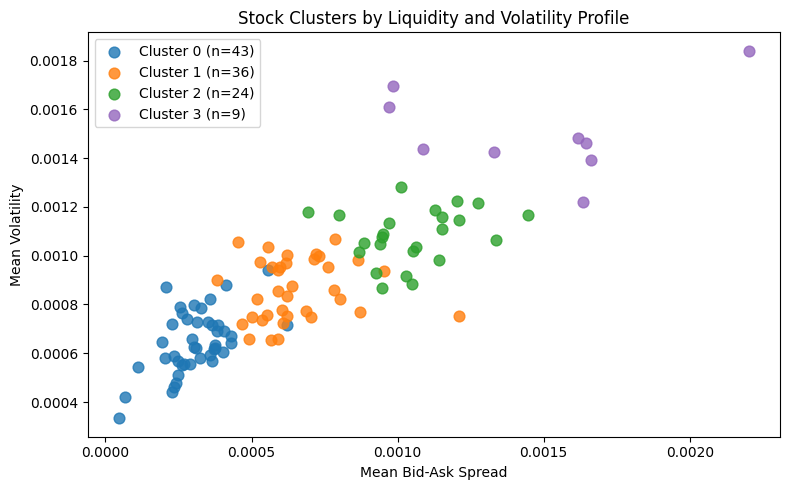

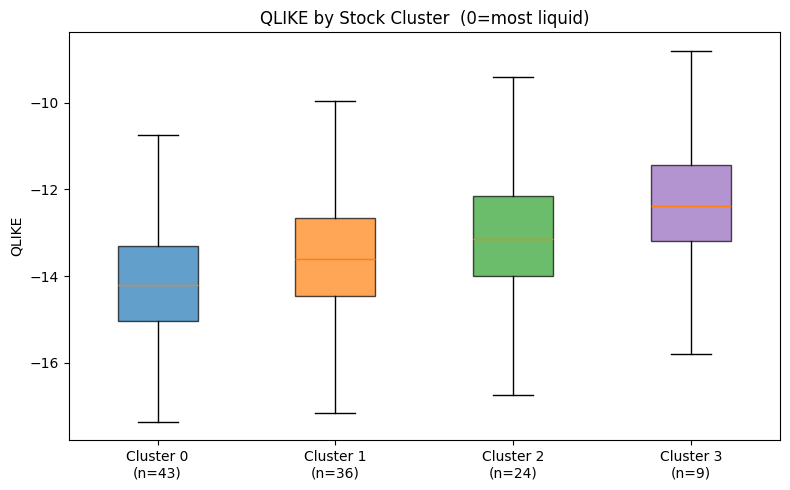

In [2]:
stock_profiles = (
    train_raw.groupby("stock_id")
    .agg(
        mean_vol    =("volatility",       "mean"),
        std_vol     =("volatility",       "std"),
        mean_spread =("BidAskSpread_mean", "mean"),
        std_spread  =("BidAskSpread_mean", "std"),
        mean_wap_std=("WAP_mean",          "std"),
    )
    .reset_index()
)

profile_features = ["mean_vol","std_vol","mean_spread","std_spread","mean_wap_std"]
X_scaled = StandardScaler().fit_transform(stock_profiles[profile_features])
kmeans   = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=20)
stock_profiles["cluster"] = kmeans.fit_predict(X_scaled)

# Sort clusters: 0 = most liquid, N-1 = most illiquid
cluster_order = (
    stock_profiles.groupby("cluster")["mean_spread"].mean()
    .sort_values().reset_index().reset_index()
    .rename(columns={"index": "new_cluster", "cluster": "old_cluster"})
)
remap = dict(zip(cluster_order["old_cluster"], cluster_order["new_cluster"]))
stock_profiles["cluster"] = stock_profiles["cluster"].map(remap)

eval_df = eval_df.merge(stock_profiles[["stock_id","cluster"]], on="stock_id", how="left")

cluster_summary = (
    eval_df.groupby("cluster")
    .agg(n_stocks=("stock_id","nunique"), n_sessions=("time_id","count"),
         mean_QLIKE=("QLIKE","mean"), median_QLIKE=("QLIKE","median"),
         mean_MSE=("MSE","mean"))
    .reset_index()
)
print(cluster_summary[["cluster","n_stocks","mean_QLIKE","mean_MSE"]].to_string(index=False))

colors4 = cm.tab10(np.linspace(0, 0.4, N_CLUSTERS))
fig, ax = plt.subplots(figsize=(8, 5))
for c in sorted(stock_profiles["cluster"].unique()):
    sub = stock_profiles[stock_profiles["cluster"] == c]
    ax.scatter(sub["mean_spread"], sub["mean_vol"],
               label=f"Cluster {c} (n={len(sub)})", color=colors4[c], s=60, alpha=0.8)
ax.set_xlabel("Mean Bid-Ask Spread"); ax.set_ylabel("Mean Volatility")
ax.set_title("Stock Clusters by Liquidity and Volatility Profile"); ax.legend()
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
cluster_data = [eval_df[eval_df["cluster"]==c]["QLIKE"].dropna().values
                for c in sorted(eval_df["cluster"].unique())]
bp = ax.boxplot(cluster_data, patch_artist=True, showfliers=False)
for patch, color in zip(bp["boxes"], colors4):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_xticklabels([f"Cluster {c}\n(n={cluster_summary.iloc[c]['n_stocks']:.0f})"
                    for c in sorted(eval_df["cluster"].unique())])
ax.set_ylabel("QLIKE"); ax.set_title("QLIKE by Stock Cluster  (0=most liquid)")
plt.tight_layout(); plt.show()

## Old Analysis 2 — Volatility Regime Detection

           regime  n_sessions  mean_QLIKE  mean_spread  mean_vol
   low-vol liquid      163876  -14.705604     0.000253  0.000395
 low-vol illiquid       41285  -13.986482     0.000650  0.000504
         stressed       12143  -13.254424     0.000858  0.000954
  high-vol liquid       46066  -13.157747     0.000318  0.000912
high-vol illiquid      158453  -12.377976     0.001165  0.001459


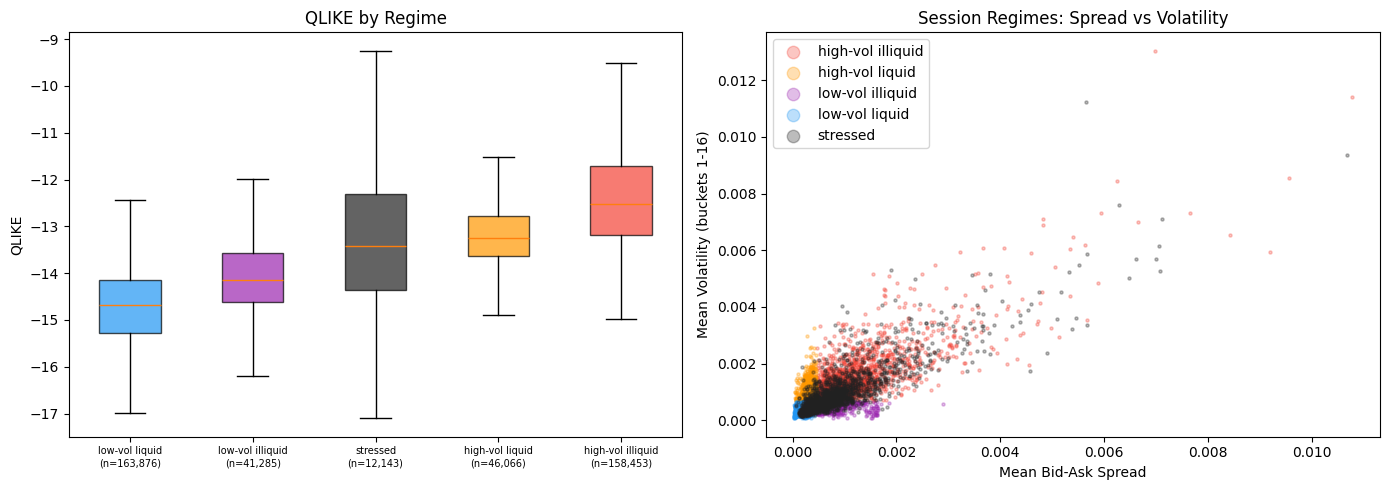

In [3]:
base  = (train_raw.groupby(["stock_id","time_id"])
         .agg(mean_vol=("volatility","mean"), mean_spread=("BidAskSpread_mean","mean"))
         .reset_index())
early = (train_raw[train_raw["time_bucket"]<=4]
         .groupby(["stock_id","time_id"])["BidAskSpread_mean"].mean()
         .reset_index().rename(columns={"BidAskSpread_mean":"spread_early"}))
late  = (train_raw[train_raw["time_bucket"]>=13]
         .groupby(["stock_id","time_id"])["BidAskSpread_mean"].mean()
         .reset_index().rename(columns={"BidAskSpread_mean":"spread_late"}))
session_stats = base.merge(early, on=["stock_id","time_id"]).merge(late, on=["stock_id","time_id"])

vol_thresh    = session_stats["mean_vol"].median()
spread_thresh = session_stats["mean_spread"].median()
spike_ratio   = session_stats["spread_late"] / session_stats["spread_early"].replace(0, np.nan)

# Vectorised regime assignment — no iterrows
conditions = [
    spike_ratio > 1.5,
    (session_stats["mean_vol"] >= vol_thresh) & (session_stats["mean_spread"] >= spread_thresh),
    (session_stats["mean_vol"] >= vol_thresh) & (session_stats["mean_spread"] <  spread_thresh),
    (session_stats["mean_vol"] <  vol_thresh) & (session_stats["mean_spread"] >= spread_thresh),
]
choices = ["stressed", "high-vol illiquid", "high-vol liquid", "low-vol illiquid"]
session_stats["regime"] = np.select(conditions, choices, default="low-vol liquid")

# Drop columns that may already exist from a previous run to avoid _x/_y collisions
eval_df = eval_df.drop(columns=["regime","mean_vol"], errors="ignore")
eval_df = eval_df.merge(
    session_stats[["stock_id","time_id","regime","mean_vol"]],
    on=["stock_id","time_id"], how="left"
)

regime_summary = (
    eval_df.groupby("regime")
    .agg(n_sessions=("time_id","count"), mean_QLIKE=("QLIKE","mean"),
         median_QLIKE=("QLIKE","median"), mean_MSE=("MSE","mean"),
         mean_vol=("mean_vol","mean"), mean_spread=("mean_spread","mean"))
    .reset_index().sort_values("mean_QLIKE")
)
print(regime_summary[["regime","n_sessions","mean_QLIKE","mean_spread","mean_vol"]].to_string(index=False))

regime_colors = {"low-vol liquid":"#2196F3","high-vol liquid":"#FF9800",
                 "low-vol illiquid":"#9C27B0","high-vol illiquid":"#F44336","stressed":"#212121"}
regime_order  = regime_summary["regime"].tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

regime_data = [eval_df[eval_df["regime"]==r]["QLIKE"].dropna().values for r in regime_order]
bp = axes[0].boxplot(regime_data, patch_artist=True, showfliers=False)
for patch, r in zip(bp["boxes"], regime_order):
    patch.set_facecolor(regime_colors.get(r,"grey")); patch.set_alpha(0.7)
axes[0].set_xticklabels(
    [f"{r}\n(n={regime_summary[regime_summary['regime']==r]['n_sessions'].values[0]:,})"
     for r in regime_order], fontsize=7)
axes[0].set_ylabel("QLIKE"); axes[0].set_title("QLIKE by Regime")

for regime, grp in eval_df.groupby("regime"):
    sample = grp.sample(min(2000, len(grp)), random_state=RANDOM_STATE)
    axes[1].scatter(sample["mean_spread"], sample["mean_vol"],
                    label=regime, color=regime_colors.get(regime,"grey"), s=5, alpha=0.3)
axes[1].set_xlabel("Mean Bid-Ask Spread"); axes[1].set_ylabel("Mean Volatility (buckets 1-16)")
axes[1].set_title("Session Regimes: Spread vs Volatility"); axes[1].legend(markerscale=4)
plt.tight_layout(); plt.show()

## New Analysis 1 — Residual Structure
Check if prediction errors are random or show systematic patterns across time_ids and stocks.

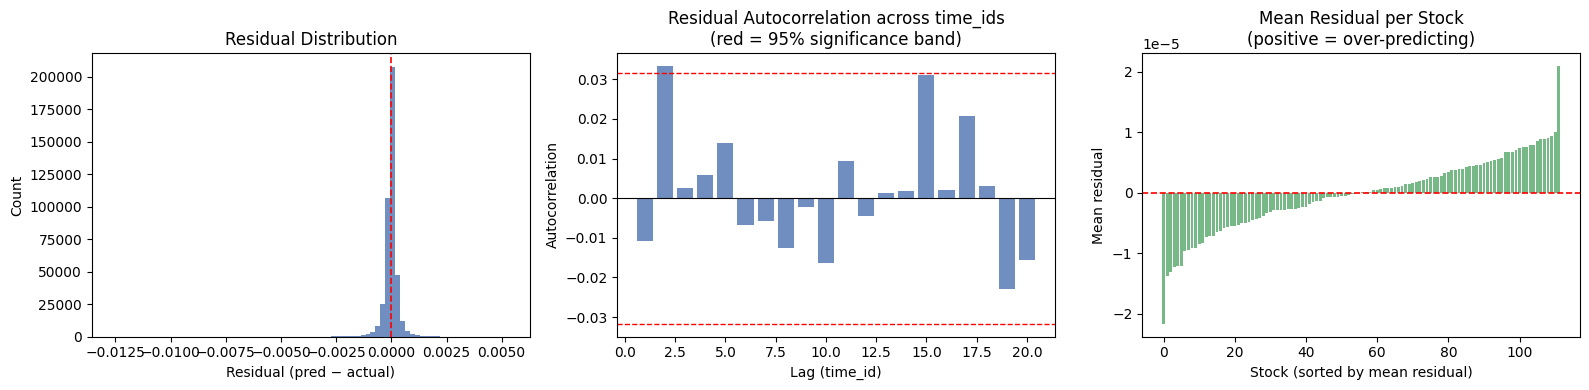

Overall mean residual : -0.000000  (+ = over-predicting)
Std of residuals      : 0.000309
Lag-1 autocorrelation : -0.0109


In [4]:
eval_df["residual"] = eval_df["pred_vol"] - eval_df["target_vol"]
eval_df["rel_error"] = eval_df["residual"] / eval_df["target_vol"].clip(lower=1e-10)

# Autocorrelation of mean residual across sorted time_ids
mean_resid_by_tid = eval_df.groupby("time_id")["residual"].mean().sort_index()
autocorrs = [mean_resid_by_tid.autocorr(lag=k) for k in range(1, 21)]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Residual distribution
axes[0].hist(eval_df["residual"], bins=80, color="#4C72B0", alpha=0.8, edgecolor="none")
axes[0].axvline(0, color="red", linewidth=1.2, linestyle="--")
axes[0].set_xlabel("Residual (pred − actual)"); axes[0].set_ylabel("Count")
axes[0].set_title("Residual Distribution")

# Autocorrelation
axes[1].bar(range(1, 21), autocorrs, color="#4C72B0", alpha=0.8)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].axhline( 1.96/np.sqrt(len(mean_resid_by_tid)), color="red", linestyle="--", linewidth=1)
axes[1].axhline(-1.96/np.sqrt(len(mean_resid_by_tid)), color="red", linestyle="--", linewidth=1)
axes[1].set_xlabel("Lag (time_id)"); axes[1].set_ylabel("Autocorrelation")
axes[1].set_title("Residual Autocorrelation across time_ids\n(red = 95% significance band)")

# Mean residual per stock (sorted)
mean_resid_by_stock = eval_df.groupby("stock_id")["residual"].mean().sort_values()
axes[2].bar(range(len(mean_resid_by_stock)), mean_resid_by_stock.values, color="#55A868", alpha=0.8)
axes[2].axhline(0, color="red", linewidth=1.2, linestyle="--")
axes[2].set_xlabel("Stock (sorted by mean residual)"); axes[2].set_ylabel("Mean residual")
axes[2].set_title("Mean Residual per Stock\n(positive = over-predicting)")

plt.tight_layout(); plt.show()

print(f"Overall mean residual : {eval_df['residual'].mean():.6f}  (+ = over-predicting)")
print(f"Std of residuals      : {eval_df['residual'].std():.6f}")
print(f"Lag-1 autocorrelation : {autocorrs[0]:.4f}")

## New Analysis 2 — Calibration / Bias per Regime
Does the model systematically over or under-predict in specific regimes?

           regime  mean_residual  mean_rel_error  pct_over  mean_pred  mean_actual      n
         stressed  -3.846181e-06        0.194312 54.525241   0.000951     0.000954  12143
high-vol illiquid  -1.000570e-06       84.293012 53.564148   0.001321     0.001322 158453
 low-vol illiquid  -5.046106e-07        0.348425 54.409592   0.000521     0.000521  41285
  high-vol liquid  -1.527743e-08        0.040313 53.186732   0.000856     0.000856  46066
   low-vol liquid   6.254603e-07        0.107722 54.174498   0.000393     0.000392 163876


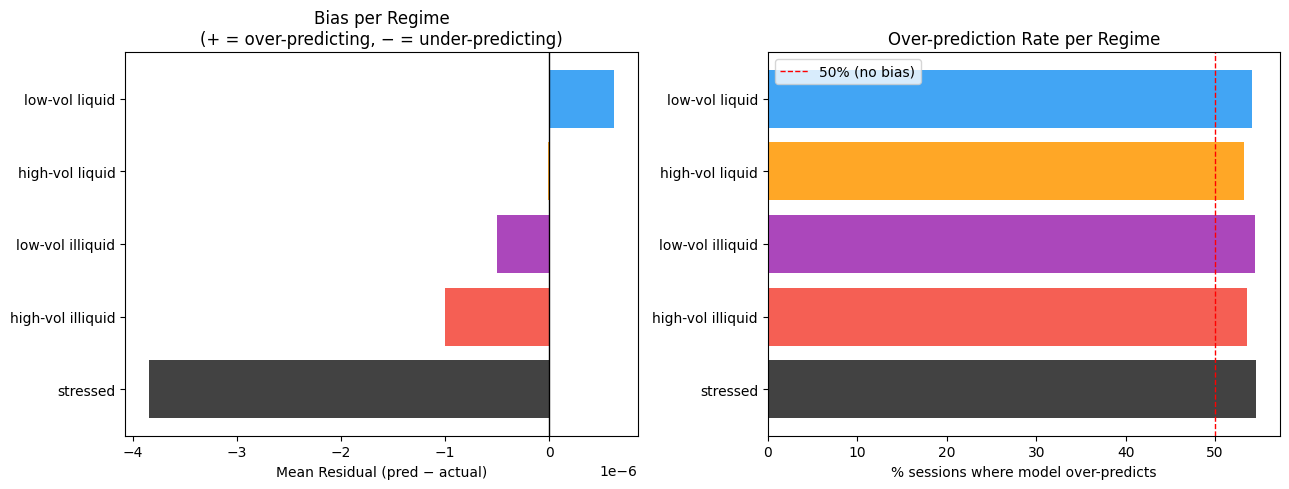

In [5]:
bias = (
    eval_df.groupby("regime")
    .agg(
        mean_residual    =("residual",  "mean"),
        mean_rel_error   =("rel_error", "mean"),
        pct_over         =("residual",  lambda x: (x > 0).mean() * 100),
        mean_pred        =("pred_vol",  "mean"),
        mean_actual      =("target_vol","mean"),
        n                =("residual",  "count"),
    )
    .reset_index()
    .sort_values("mean_residual")
)
print(bias.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors_r = [regime_colors.get(r, "grey") for r in bias["regime"]]
bars = axes[0].barh(bias["regime"], bias["mean_residual"], color=colors_r, alpha=0.85)
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_xlabel("Mean Residual (pred − actual)")
axes[0].set_title("Bias per Regime\n(+ = over-predicting, − = under-predicting)")

axes[1].barh(bias["regime"], bias["pct_over"], color=colors_r, alpha=0.85)
axes[1].axvline(50, color="red", linewidth=1, linestyle="--", label="50% (no bias)")
axes[1].set_xlabel("% sessions where model over-predicts")
axes[1].set_title("Over-prediction Rate per Regime"); axes[1].legend()

plt.tight_layout(); plt.show()

## New Analysis 3 — Feature Importance

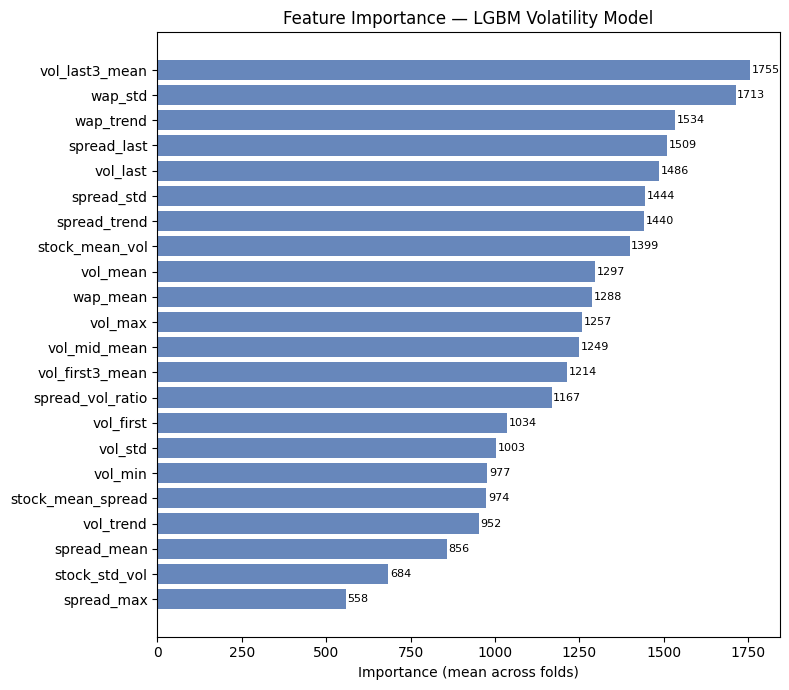

Top 5 features:
       feature  importance
vol_last3_mean      1755.4
       wap_std      1712.6
     wap_trend      1533.8
   spread_last      1509.2
      vol_last      1485.8


In [6]:
fig, ax = plt.subplots(figsize=(8, 7))
fi = feat_imp.sort_values("importance")
bars = ax.barh(fi["feature"], fi["importance"], color="#4C72B0", alpha=0.85)
ax.set_xlabel("Importance (mean across folds)")
ax.set_title("Feature Importance — LGBM Volatility Model")
# Annotate values
for bar, val in zip(bars, fi["importance"]):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2,
            f"{val:.0f}", va="center", fontsize=8)
plt.tight_layout(); plt.show()

print("Top 5 features:")
print(feat_imp.sort_values("importance", ascending=False).head().to_string(index=False))

## New Analysis 4 — Directional Accuracy
Can the model correctly predict whether volatility will be above or below the session's own training average?

Overall directional accuracy : 61.4%

Directional accuracy per regime:
           regime  accuracy      n
 low-vol illiquid 56.715514  41285
   low-vol liquid 57.815055 163876
         stressed 57.975789  12143
high-vol illiquid 65.059040 158453
  high-vol liquid 66.406894  46066


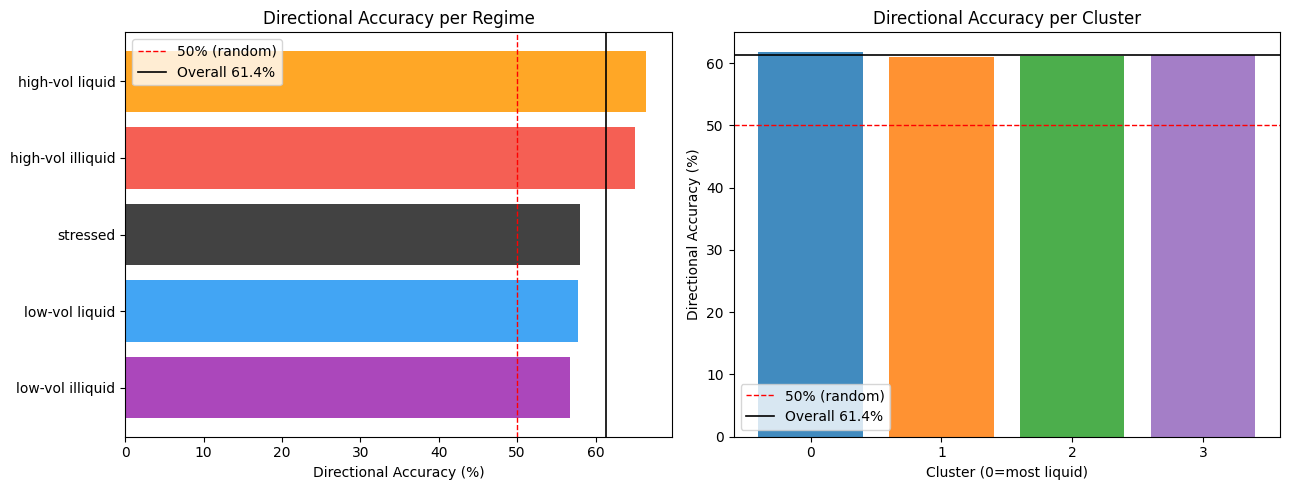

In [7]:
# Baseline = mean volatility from buckets 1-16 for each session
baseline = (
    train_raw.groupby(["stock_id","time_id"])["volatility"]
    .mean().reset_index()
    .rename(columns={"volatility":"train_mean_vol"})
)
eval_df = eval_df.merge(baseline, on=["stock_id","time_id"], how="left")

# Direction: did val vol go up or down vs training mean?
eval_df["actual_up"]    = eval_df["target_vol"] > eval_df["train_mean_vol"]
eval_df["predicted_up"] = eval_df["pred_vol"]   > eval_df["train_mean_vol"]
eval_df["dir_correct"]  = eval_df["actual_up"]  == eval_df["predicted_up"]

overall_acc = eval_df["dir_correct"].mean() * 100
print(f"Overall directional accuracy : {overall_acc:.1f}%")

# Per regime
dir_by_regime = (
    eval_df.groupby("regime")["dir_correct"]
    .agg(accuracy=lambda x: x.mean()*100, n="count")
    .reset_index().sort_values("accuracy")
)
print("\nDirectional accuracy per regime:")
print(dir_by_regime.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors_r2 = [regime_colors.get(r,"grey") for r in dir_by_regime["regime"]]
axes[0].barh(dir_by_regime["regime"], dir_by_regime["accuracy"], color=colors_r2, alpha=0.85)
axes[0].axvline(50, color="red", linestyle="--", linewidth=1, label="50% (random)")
axes[0].axvline(overall_acc, color="black", linestyle="-", linewidth=1.2,
                label=f"Overall {overall_acc:.1f}%")
axes[0].set_xlabel("Directional Accuracy (%)"); axes[0].set_title("Directional Accuracy per Regime")
axes[0].legend()

# Per cluster
dir_by_cluster = (
    eval_df.groupby("cluster")["dir_correct"]
    .agg(accuracy=lambda x: x.mean()*100, n="count")
    .reset_index()
)
axes[1].bar(dir_by_cluster["cluster"].astype(str), dir_by_cluster["accuracy"],
            color=colors4, alpha=0.85)
axes[1].axhline(50, color="red", linestyle="--", linewidth=1, label="50% (random)")
axes[1].axhline(overall_acc, color="black", linestyle="-", linewidth=1.2,
                label=f"Overall {overall_acc:.1f}%")
axes[1].set_xlabel("Cluster (0=most liquid)"); axes[1].set_ylabel("Directional Accuracy (%)")
axes[1].set_title("Directional Accuracy per Cluster"); axes[1].legend()

plt.tight_layout(); plt.show()

## New Analysis 5 — Worst-case Analysis
Which sessions have the worst QLIKE and what do they have in common?

Worst 5% threshold QLIKE >= -11.050  (21,092 sessions)

-- Regime breakdown (worst vs best) --
                   worst_%  best_%
regime                            
high-vol illiquid     87.8     NaN
stressed               5.1     1.7
low-vol illiquid       3.5     3.0
low-vol liquid         2.3    95.2
high-vol liquid        1.4     NaN

-- Cluster breakdown (worst vs best) --
         worst_%  best_%
cluster                 
2           35.6     3.3
3           26.4     0.1
1           25.9    21.9
0           12.2    74.6


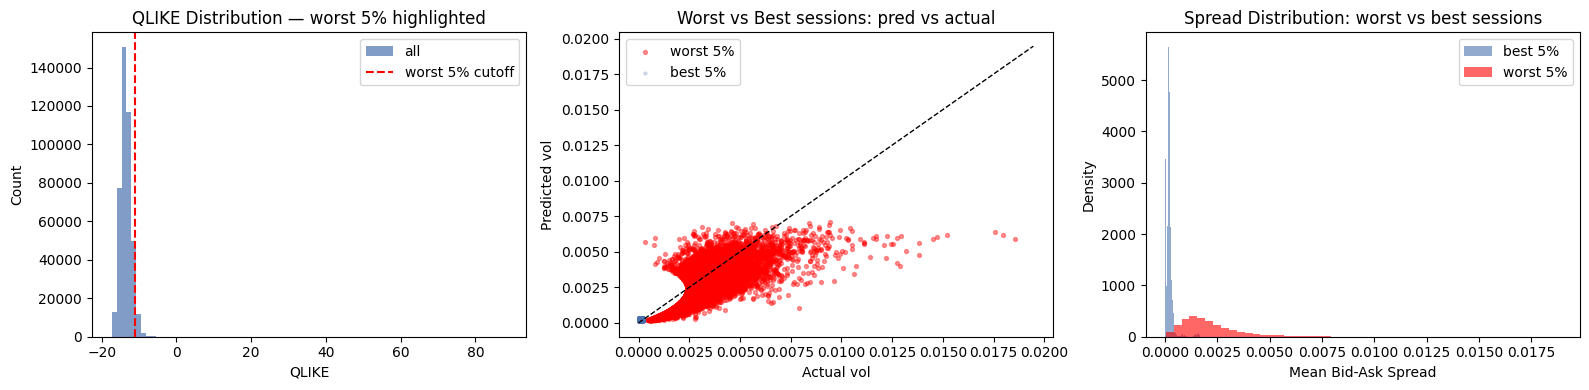

In [8]:
WORST_PCT = 5   # top % worst sessions

thresh   = eval_df["QLIKE"].quantile(1 - WORST_PCT/100)
worst    = eval_df[eval_df["QLIKE"] >= thresh].copy()
best     = eval_df[eval_df["QLIKE"] <  eval_df["QLIKE"].quantile(WORST_PCT/100)].copy()

print(f"Worst {WORST_PCT}% threshold QLIKE >= {thresh:.3f}  ({len(worst):,} sessions)")

print("\n-- Regime breakdown (worst vs best) --")
wr = worst["regime"].value_counts(normalize=True).rename("worst_%")
br = best["regime"].value_counts(normalize=True).rename("best_%")
print(pd.concat([wr*100, br*100], axis=1).round(1).to_string())

print("\n-- Cluster breakdown (worst vs best) --")
wc = worst["cluster"].value_counts(normalize=True).rename("worst_%")
bc = best["cluster"].value_counts(normalize=True).rename("best_%")
print(pd.concat([wc*100, bc*100], axis=1).round(1).to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# QLIKE tail
axes[0].hist(eval_df["QLIKE"], bins=80, color="#4C72B0", alpha=0.7, label="all")
axes[0].axvline(thresh, color="red", linewidth=1.5, linestyle="--",
                label=f"worst {WORST_PCT}% cutoff")
axes[0].set_xlabel("QLIKE"); axes[0].set_ylabel("Count")
axes[0].set_title(f"QLIKE Distribution — worst {WORST_PCT}% highlighted")
axes[0].legend()

# Worst sessions: pred vs actual
axes[1].scatter(worst["target_vol"], worst["pred_vol"], alpha=0.4, s=8, color="red", label="worst 5%")
axes[1].scatter(best["target_vol"],  best["pred_vol"],  alpha=0.2, s=5, color="#4C72B0", label="best 5%")
lim = eval_df[["target_vol","pred_vol"]].max().max() * 1.05
axes[1].plot([0,lim],[0,lim], "k--", linewidth=1)
axes[1].set_xlabel("Actual vol"); axes[1].set_ylabel("Predicted vol")
axes[1].set_title("Worst vs Best sessions: pred vs actual"); axes[1].legend()

# Spread distribution: worst vs best
axes[2].hist(best["mean_spread"],  bins=50, alpha=0.6, color="#4C72B0", label="best 5%",  density=True)
axes[2].hist(worst["mean_spread"], bins=50, alpha=0.6, color="red",     label="worst 5%", density=True)
axes[2].set_xlabel("Mean Bid-Ask Spread"); axes[2].set_ylabel("Density")
axes[2].set_title("Spread Distribution: worst vs best sessions"); axes[2].legend()

plt.tight_layout(); plt.show()

## New Analysis 6 — Cross-stock Generalisation
Does the model generalise equally across stock types, or is it dominated by one cluster?

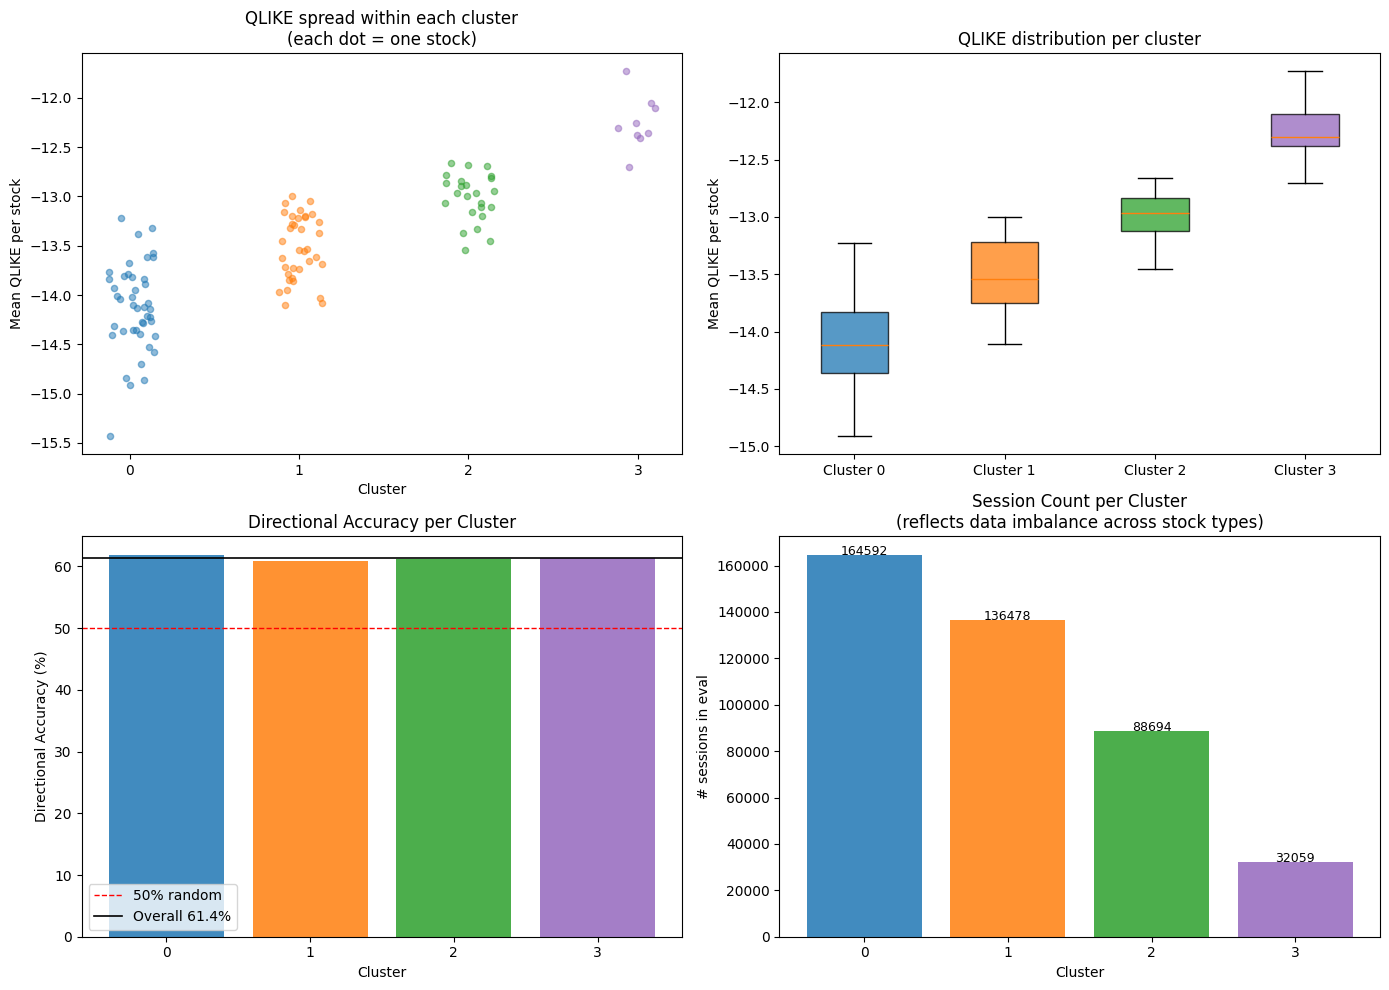


Per-cluster summary:
         mean_QLIKE  dir_acc  n_sessions
cluster                                 
0            -14.13    61.86      164592
1            -13.52    60.93      136478
2            -13.01    61.17       88694
3            -12.25    61.32       32059


In [9]:
cluster_detail = (
    eval_df.groupby(["cluster","stock_id"])
    .agg(mean_QLIKE=("QLIKE","mean"), mean_MSE=("MSE","mean"),
         dir_acc=("dir_correct", lambda x: x.mean()*100),
         n_sessions=("time_id","count"))
    .reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for c in sorted(cluster_detail["cluster"].unique()):
    sub = cluster_detail[cluster_detail["cluster"]==c]

    # QLIKE distribution per stock within cluster
    axes[0, 0].scatter(
        [c]*len(sub) + np.random.uniform(-0.15, 0.15, len(sub)),
        sub["mean_QLIKE"], alpha=0.5, s=20, color=colors4[c]
    )
axes[0,0].set_xticks(sorted(cluster_detail["cluster"].unique()))
axes[0,0].set_xlabel("Cluster"); axes[0,0].set_ylabel("Mean QLIKE per stock")
axes[0,0].set_title("QLIKE spread within each cluster\n(each dot = one stock)")

# Mean QLIKE per cluster (box)
cluster_qlike = [cluster_detail[cluster_detail["cluster"]==c]["mean_QLIKE"].values
                 for c in sorted(cluster_detail["cluster"].unique())]
bp = axes[0,1].boxplot(cluster_qlike, patch_artist=True, showfliers=False)
for patch, c in zip(bp["boxes"], colors4):
    patch.set_facecolor(c); patch.set_alpha(0.75)
axes[0,1].set_xticklabels([f"Cluster {c}" for c in sorted(cluster_detail["cluster"].unique())])
axes[0,1].set_ylabel("Mean QLIKE per stock")
axes[0,1].set_title("QLIKE distribution per cluster")

# Directional accuracy per cluster
dir_cluster = cluster_detail.groupby("cluster")["dir_acc"].mean()
axes[1,0].bar(dir_cluster.index.astype(str), dir_cluster.values, color=colors4, alpha=0.85)
axes[1,0].axhline(50,  color="red",   linestyle="--", linewidth=1, label="50% random")
axes[1,0].axhline(overall_acc, color="black", linestyle="-", linewidth=1.2,
                  label=f"Overall {overall_acc:.1f}%")
axes[1,0].set_xlabel("Cluster"); axes[1,0].set_ylabel("Directional Accuracy (%)")
axes[1,0].set_title("Directional Accuracy per Cluster"); axes[1,0].legend()

# Sessions per cluster
n_sess = eval_df.groupby("cluster")["time_id"].count()
axes[1,1].bar(n_sess.index.astype(str), n_sess.values, color=colors4, alpha=0.85)
axes[1,1].set_xlabel("Cluster"); axes[1,1].set_ylabel("# sessions in eval")
axes[1,1].set_title("Session Count per Cluster\n(reflects data imbalance across stock types)")
for i, v in enumerate(n_sess.values):
    axes[1,1].text(i, v + 50, str(v), ha="center", fontsize=9)

plt.tight_layout(); plt.show()

print("\nPer-cluster summary:")
print(cluster_detail.groupby("cluster")[["mean_QLIKE","dir_acc","n_sessions"]]
      .agg({"mean_QLIKE":"mean","dir_acc":"mean","n_sessions":"sum"})
      .round(2).to_string())